In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_classic.chains.query_constructor.base import StructuredQueryOutputParser
from langchain_classic.chains.query_constructor.base import get_query_constructor_prompt
from langchain_core.documents import Document
from langchain_classic.chains.query_constructor.schema import AttributeInfo
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_classic.retrievers.self_query.base import SelfQueryRetriever
from langchain_community.query_constructors.chroma import ChromaTranslator
from dotenv import load_dotenv
from typing import List, Dict, Union, Optional
import hashlib
import pandas as pd
import re

In [2]:
load_dotenv()
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("buyeragent-rag")

LangSmith 추적을 시작합니다.
[프로젝트명]
buyeragent-rag


### 최종 수정한 코드

### 1. DF에서 Docs로 변환

In [3]:
pd.set_option("display.max_colwidth", None)
df = pd.read_csv("./Crawling/crawler_result.csv")


def normalize_price(v):
    if pd.isna(v):
        return 0
    digits = re.sub(r"[^\d]", "", str(v))
    return int(digits) if digits else 0


def normalize_sizes(text):
    if pd.isna(text):
        return []
    tokens = re.findall(r"\d{2,3}", str(text))
    return sorted(set(int(t) for t in tokens))


def normalize_age_group(name):
    t = str(name)
    if re.search(r"주니어|JR|키즈|유소년", t, re.I):
        return "유소년용"
    return "성인용"


def normalize_ground(name):
    t = str(name).upper()

    if "FG" in t:
        return "FG"
    if "AG" in t:
        return "AG"
    if "MG" in t:
        return "MG"
    if "HG" in t:
        return "HG"
    if "TF" in t or "TURF" in t:
        return "TF"

    return "UNKNOWN"


def normalize_category(name):
    t = str(name)

    if re.search(r"풋살|TF", t, re.I):
        return "풋살화"

    return "축구화"


# 정규화 적용
df["product_price"] = df["product_price"].apply(normalize_price)
df["product_size"] = df["sizes_text"].apply(normalize_sizes)
df["age_group"] = df["product_name"].apply(normalize_age_group)
df["ground_type"] = df["product_name"].apply(normalize_ground)
df["product_category"] = df["product_name"].apply(normalize_category)


def _normalize_sizes(value) -> list[int]:
    """
    product_size 값을 list[int]로 정규화
    지원 예:
    - [230, 235, 240]
    - "230, 235, 240"
    - "[230, 235, 240]"
    - NaN / None
    """
    if value is None:
        return []

    if pd.isna(value) if not isinstance(value, (list, tuple, set)) else False:
        return []

    if isinstance(value, list):
        out = []
        for x in value:
            try:
                n = int(x)
                if 0 < n < 400:
                    out.append(n)
            except Exception:
                pass
        return sorted(set(out))

    if isinstance(value, (tuple, set)):
        out = []
        for x in value:
            try:
                n = int(x)
                if 0 < n < 400:
                    out.append(n)
            except Exception:
                pass
        return sorted(set(out))

    text = str(value)
    nums = re.findall(r"\d{2,3}", text)
    out = []
    for x in nums:
        try:
            n = int(x)
            if 0 < n < 400:
                out.append(n)
        except Exception:
            pass

    return sorted(set(out))


def _clean_product_name(name: str) -> str:
    """
    검색 품질을 해칠 수 있는 판촉 문구/기호를 간단 정리
    """
    t = str(name or "").strip()
    t = re.sub(r"\[[^\]]+\]", " ", t)  # [40%세일특가]
    t = re.sub(r"#", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def build_page_content(row: pd.Series) -> str:
    SELLER_KR_MAP = {
        "crazy11": "크레이지11",
        "soccerboom": "사커붐",
        "redsoccer": "레드사커",
        "cafostore": "카포스토어",
    }
    product_name = _clean_product_name(row.get("product_name", "정보없음"))
    seller_raw = row.get("seller", "미상") or "미상"
    seller = SELLER_KR_MAP.get(seller_raw, seller_raw)
    price = int(row.get("product_price", 0) or 0)

    product_category = row.get("product_category", "정보없음") or "정보없음"
    age_group = row.get("age_group", "정보없음") or "정보없음"
    ground_type = row.get("ground_type", "정보없음") or "정보없음"

    sizes = _normalize_sizes(row.get("product_size", []))
    size_text = ", ".join(map(str, sizes)) if sizes else "정보없음"

    lines = [
        f"상품명: {product_name}",
        f"판매자: {seller}",
        f"카테고리: {product_category}",
        f"연령대: {age_group}",
        f"지면: {ground_type}",
        f"가격: {price}원",
        f"사이즈: {size_text}",
    ]

    return "\n".join(lines)


def row_to_document(row: pd.Series) -> Document:
    SELLER_KR_MAP = {
        "crazy11": "크레이지11",
        "soccerboom": "사커붐",
        "redsoccer": "레드사커",
        "cafostore": "카포스토어",
    }
    product_name = _clean_product_name(row.get("product_name", "정보없음"))
    sizes = _normalize_sizes(row.get("product_size", []))
    seller_raw = row.get("seller", "미상")
    seller_kr = SELLER_KR_MAP.get(seller_raw, seller_raw)
    metadata = {
        "seller": seller_kr,
        "product_name": product_name,
        "product_price": int(row.get("product_price", 0) or 0),
        # 서비스용 사이즈 구조
        "available_sizes": sizes,
        "size_min": min(sizes) if sizes else None,
        "size_max": max(sizes) if sizes else None,
        "size_text": ",".join(map(str, sizes)) if sizes else "",
        "product_category": row.get("product_category", "정보없음"),
        "age_group": row.get("age_group", "정보없음"),
        "ground_type": row.get("ground_type", "정보없음"),
        "product_url": row.get("product_url", ""),
        "image_url": row.get("image_url", ""),
    }

    page_content = build_page_content(row)

    return Document(
        page_content=page_content,
        metadata=metadata,
    )


def dataframe_to_documents(df: pd.DataFrame) -> list[Document]:
    return [row_to_document(row) for _, row in df.iterrows()]


docs = dataframe_to_documents(df)

In [ ]:
docs

### 2. vectorstore 및 제품 메타데이터 설정

In [5]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embedding = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
# retriever에 동일한 문서가 들어가는 것을 방지하기 위한 각 문서마다 고정 id 부여
import hashlib

ids = [
    hashlib.sha1(d.metadata["product_url"].encode("utf-8")).hexdigest() for d in docs
]
vectorstore = Chroma(embedding_function=embedding)
vectorstore.add_documents(docs, ids=ids)
# vectorstore = Chroma.from_documents(documents=docs, embedding=embedding, ids=ids)
# print(f"벡터스토어에 {len(docs)}개 문서 삽입 완료")

metadata_info = [
    AttributeInfo(
        name="seller",
        description="제품을 판매하는 판매처 또는 사이트명",
        type="string",
    ),
    AttributeInfo(
        name="product_name",
        description="제품명",
        type="string",
    ),
    AttributeInfo(
        name="product_price",
        description="제품 판매 가격. 숫자형 원 단위",
        type="integer",
    ),
    AttributeInfo(
        name="product_category",
        description="제품 카테고리. 축구화 또는 풋살화",
        type="string",
    ),
    AttributeInfo(
        name="age_group",
        description="사용 연령대. 예: 성인용, 유소년용",
        type="string",
    ),
    AttributeInfo(
        name="ground_type",
        description="지면 종류. 예: FG, AG, HG, TF",
        type="string",
    ),
]

document_contents = """
여러 판매처에서 수집한 축구화 상품 문서입니다.
각 문서에는 상품명, 판매처, 가격, 카테고리, 연령대, 지면 종류가 포함됩니다.
사이즈 정보는 page_content 안에 텍스트로 포함되어 있습니다.
"""

벡터스토어에 45개 문서 삽입 완료


### query_constructor chain 및 retriever 생성

In [57]:
# 문서 내용 설명과 메타데이터 필드 정보를 사용하여 쿼리 생성기 프롬프트를 가져옵니다.
prompt = get_query_constructor_prompt(
    """
    여러 판매처에서 수집한 축구화 제품 문서
        1. 가격 표현 해석 규칙:
         - 10만원대 = 100000 이상 200000 미만
         - 20만원대 = 200000 이상 300000 미만
         - 15만원대 = 150000 이상 160000 미만
         - 10만원 이상 = 100000 이상
         - 10만원 이하 = 100000 이하
        2. 카테고리 표현 해석 규칙:
        - 축구화: product_category == 축구화
        - 풋살화: product_category == 풋살화
    """,  # 문서 내용 설명
    metadata_info,  # 메타데이터 필드 정보
)

# StructuredQueryOutputParser 를 생성
output_parser = StructuredQueryOutputParser.from_components()

# query_constructor chain 을 생성
query_constructor = prompt | model | output_parser

retriever = SelfQueryRetriever(
    query_constructor=query_constructor,  # 이전에 생성한 query_constructor chain 을 지정
    vectorstore=vectorstore,  # 벡터 저장소를 지정
    structured_query_translator=ChromaTranslator(),  # 쿼리 변환기
)

### Retriever Test

In [ ]:
# 1. 문서별로 고정 id 부여 후, 검색 테스트
## 중복되는 문서 -> 해결
# 2. 판매자 2명이상인 경우 -> 병렬화 진행
retriever.invoke(
    # 질문
    "크레이지11과 사커붐에서 사이즈가 250인 머큐리얼 성인용 축구화 10만원대 추천해줘"
)

[Document(id='ab0643953aecefdf23322b21cf52ec9f157e5930', metadata={'product_price': 132800, 'product_name': '줌 머큐리얼 베이퍼 16 프로 KM FG(FQ8689-801)(FQ8689801)', 'size_min': 245, 'seller': '사커붐', 'size_text': '245,250,255,260,265,270,275,285,290,295,300', 'available_sizes': [245, 250, 255, 260, 265, 270, 275, 285, 290, 295, 300], 'size_max': 300, 'product_category': '축구화', 'product_url': 'https://soccerboom.co.kr/product/줌-머큐리얼-베이퍼-16-프로-km-fgfq8689-801fq8689801/51583/category/25/display/1/', 'image_url': 'https://soccerboom.co.kr/web/product/medium/202510/b265516a1fa9bc67964a2f90163efabf.jpg', 'ground_type': 'FG', 'age_group': '성인용'}, page_content='상품명: 줌 머큐리얼 베이퍼 16 프로 KM FG(FQ8689-801)(FQ8689801)\n판매자: 사커붐\n카테고리: 축구화\n연령대: 성인용\n지면: FG\n가격: 132800원\n사이즈: 245, 250, 255, 260, 265, 270, 275, 285, 290, 295, 300'),
 Document(id='acf36f22d6a7bfa93a9f04df82988d84b6638c48', metadata={'size_text': '230,235,240,245,250,255,260,265,270,275,280', 'available_sizes': [230, 235, 240, 245, 250, 255, 260,

In [37]:
retriever.invoke(
    # 질문
    "크레이지11과 사커붐에서 사이즈가 250인 머큐리얼 성인용 축구화 10만원대 추천해줘"
)

[Document(id='ab0643953aecefdf23322b21cf52ec9f157e5930', metadata={'size_min': 245, 'product_price': 132800, 'product_category': '축구화', 'image_url': 'https://soccerboom.co.kr/web/product/medium/202510/b265516a1fa9bc67964a2f90163efabf.jpg', 'size_max': 300, 'available_sizes': [245, 250, 255, 260, 265, 270, 275, 285, 290, 295, 300], 'size_text': '245,250,255,260,265,270,275,285,290,295,300', 'ground_type': 'FG', 'seller': '사커붐', 'product_url': 'https://soccerboom.co.kr/product/줌-머큐리얼-베이퍼-16-프로-km-fgfq8689-801fq8689801/51583/category/25/display/1/', 'product_name': '줌 머큐리얼 베이퍼 16 프로 KM FG(FQ8689-801)(FQ8689801)', 'age_group': '성인용'}, page_content='상품명: 줌 머큐리얼 베이퍼 16 프로 KM FG(FQ8689-801)(FQ8689801)\n판매자: 사커붐\n카테고리: 축구화\n연령대: 성인용\n지면: FG\n가격: 132800원\n사이즈: 245, 250, 255, 260, 265, 270, 275, 285, 290, 295, 300'),
 Document(id='acf36f22d6a7bfa93a9f04df82988d84b6638c48', metadata={'available_sizes': [230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280], 'size_text': '230,235,240,245,250,255,

### 병렬 Retriever 및 Generation Test
- 사용자가 2개 이상의 판매자를 요청했을 때 검색하기 위함

In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from concurrent.futures import ThreadPoolExecutor, as_completed
import re

SELLER_KEYWORDS = {
    "크레이지11": "크레이지11",
    "crazy11": "크레이지11",
    "사커붐": "사커붐",
    "soccerboom": "사커붐",
    "레드사커": "레드사커",
    "redsoccer": "레드사커",
    "카포스토어": "카포스토어",
    "cafostore": "카포스토어",
}


def extract_sellers_from_query(query: str) -> list[str]:
    found = []
    for keyword, seller in SELLER_KEYWORDS.items():
        if keyword in query and seller not in found:
            found.append(seller)
    return found


def parallel_retrieve(query: str) -> list:
    sellers = extract_sellers_from_query(query)

    if len(sellers) <= 1:
        return retriever.invoke(query)

    def search_per_seller(seller: str) -> list:
        sub_query = f"{seller}에서 " + re.sub(
            r"([\w가-힣]+(?:과|와|,)\s*)+[\w가-힣]+에서\s*", "", query
        )
        return retriever.invoke(sub_query)

    seen_ids = set()
    results = []

    with ThreadPoolExecutor(max_workers=len(sellers)) as executor:
        futures = {executor.submit(search_per_seller, s): s for s in sellers}
        for future in as_completed(futures):
            for doc in future.result():
                key = doc.metadata.get("product_url", doc.id or "")
                if key not in seen_ids:
                    seen_ids.add(key)
                    results.append(doc)

    return results


def format_docs(docs: list) -> str:
    items = []
    for doc in docs:
        url = doc.metadata.get("product_url", "")
        image = doc.metadata.get("image_url", "")
        item = doc.page_content
        if url:
            item += f"\n상품 URL: {url}"
        if image:
            item += f"\n이미지 URL: {image}"
        items.append(item)
    return "\n\n".join(items)


# RunnableLambda로 감싸기
parallel_retriever = RunnableLambda(parallel_retrieve)

prompt = PromptTemplate.from_template(
    """
        You are a product comparison assistant specializing in soccer shoes.
        Your role is to answer user queries by analyzing structured product data retrieved from multiple online sources.  
        Each product is represented as a structured object with the following fields:
        ---

        ## Product Metadata Fields

        - `seller` (string): 제품을 판매하는 판매처명 또는 사이트명
        - `product_name` (string): 제품명
        - `product_price` (integer): 제품 판매가 (₩)
        - `product_size` (integer): 제품 사이즈 
        - `product_category` (string): 제품 카테고리 (예: "축구화", "풋살화")
        - `age_group` (string): 사용 연령대 (예: "유소년용", "성인용")
        - `ground_type` (string): 지면 종류 (예: "FG", "AG", "SG", "HG", "TF")
        - `product_url` (string): 제품 상세 URL 문자열
        - `product_images` (string): 제품 이미지의 URL 문자열 (단일 이미지)
        ---

        ## Objective

        Your task is to extract up to **3 soccer shoes**:

        - **product_name**
        - **product_price**
        - **product_category**
        - **age_group**
        - **ground_type**
        - **기능 키워드** (예: 경량성, 내구성, 접지력, 슈팅 성능 등)
        - **카테고리**: `age_group`과 `ground_type` 조합으로 판단
            - 예: 유소년용 풋살화 → age_group = "유소년용" & ground_type = "TF"
        - 제품이 **3개 이하인 경우**, **가능한 모든 관련 제품을 포함**하세요.

        Use only the information provided in the context variable.
        ---

        ## Output Instructions

        - Return a **Markdown table**
        - 각 항목에 포함해야 할 정보:
        - `판매처 (seller)`
        - `상품명 (product_name)`
        - `가격 (product_price)`
        - `사이즈` (product_size)
        - `주요 특징 (features)`:
            - 기능 키워드 기반으로 최소 3가지 이상 구체적 특징 작성
            - `ground_type` 값을 해석하여 **어떤 지면에 적합한지 설명 포함**
            (예: ✔ TF 스터드 (인조잔디용), ✔ FG 스터드 (천연잔디용))
            - `age_group`을 반영해 **사용 연령대** 명시
        - `링크`: `product_url` 필드의 **URL 문자열을 그대로** 사용하여 마크다운 출력 (링크에 jpg, png이 제외된 링크)
        - `이미지`: `product_images` 필드의 **URL 문자열을 그대로** 사용하여 마크다운 이미지 출력 (링크에 jpg, png이 포함된 링크) 
        ---

        ## User Question
        {question}

        ---
        ## Product Context
        {context}

        ---
        ## Output Format Example

        **✅ 축구화 제품 비교표**

        | 판매처     | 상품명                              | 가격      | 주요 특징 | 이미지 | 링크 |
        |------------|-------------------------------------|-----------|---------------------------------------------------|--------|---------------------------------------------------|
        | 크레이지11 | 나이키 머큐리얼 베이퍼 16 프로 TF | ₩89,000 | ✔ 경량성, ✔ TF 스터드 (인조잔디용), ✔ 유소년용, ✔ 내구성 강화| ![이미지](https://example.com/image1.jpg) | [🔗 제품 상세보기](https://example.com/url1) |
        | 사커붐     | 머큐리얼 베이퍼 16 KM FG | ₩113,900 | ✔ 스피드 향상, ✔ FG 스터드 (천연잔디용), ✔ 성인용, ✔ 슈팅 퍼포먼스 향상 | ![이미지](https://example.com/image2.jpg)|[🔗 제품 상세보기](https://example.com/url2) |
        | 레드사커   | 나이키 줌 머큐리얼 베이퍼 16 AG | ₩152,900 | ✔ 스피드 향상, ✔ FG 스터드 (천연잔디용), ✔ 성인용, ✔ 슈팅 퍼포먼스 향상 | ![이미지](https://example.com/image3.jpg)|[🔗 제품 상세보기](https://example.com/url3) |        
        ---

        ## Restrictions
        - 절대 제품 정보를 임의로 생성하지 마세요.
        - 단, 만약 정말로 검색 결과가 없을 경우에만 아래 문장을 출력하세요. 그렇지 않다면 절대로 아래 문장을 포함하지 마세요.
            - "요청하신 조건에 부합하는 축구화 정보를 찾을 수 없습니다."
        """
)

chain = (
    {"context": parallel_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

# 실행
response = chain.invoke(
    "크레이지11과 사커붐에서 사이즈가 250인 머큐리얼 성인용 축구화 10만원대 추천해줘"
)
print(response)

### LangGraph (with RAG)

```
START
  ↓
classify_intent
  ↓              ↓
"search"      "chitchat"
"refine"         ↓
  ↓          respond_directly → END
rewrite_query  (히스토리로 완전한 쿼리 재구성)
  ↓
retrieve
  ↓
grade_docs
  ↓              ↓
"relevant"   "irrelevant"
  ↓              ↓
generate    ask_clarification → END
  ↓
END
```


In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict, Annotated, Literal


# ── 1. State ───────────────────────────────────────────────
class State(TypedDict):
    messages: Annotated[list, add_messages]
    intent: str  # "search" | "refine" | "chitchat"
    refined_query: str  # rewrite된 검색 쿼리
    context: str  # format_docs 결과
    doc_grade: str  # "relevant" | "irrelevant"


# ── 2. Node: classify_intent ───────────────────────────────
def classify_intent(state: State) -> dict:
    """
    사용자 의도 분류
    - search   : 새로운 제품 검색
    - refine   : 이전 검색 조건 수정/추가
    - chitchat : 검색 무관 대화
    """
    last_msg = state["messages"][-1].content
    history = state["messages"][:-1]

    classifier = (
        ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """사용자 메시지의 의도를 분류하세요. 반드시 아래 중 하나만 출력하세요.
- search   : 축구화/풋살화 신규 검색 요청
- refine   : 이전 검색 결과에 조건 변경/추가 요청 (예: "AG로 다시", "더 저렴한 걸로")
- chitchat : 검색과 무관한 대화 (인사, 감사, 잡담 등)

의도만 출력하세요. 설명 없이.""",
                ),
                MessagesPlaceholder("history"),
                ("human", "{question}"),
            ]
        )
        | model
        | StrOutputParser()
    )

    intent = (
        classifier.invoke(
            {
                "history": history,
                "question": last_msg,
            }
        )
        .strip()
        .lower()
    )

    if intent not in ("search", "refine", "chitchat"):
        intent = "search"

    return {"intent": intent}


# ── 3. Node: rewrite_query ─────────────────────────────────
def rewrite_query(state: State) -> dict:
    """
    refine인 경우 히스토리를 참고해 완전한 검색 쿼리로 재구성
    search인 경우 그대로 사용
    """
    last_msg = state["messages"][-1].content

    if state["intent"] == "search":
        return {"refined_query": last_msg}

    # refine: 이전 대화에서 누적 조건 추출 후 새 조건 반영
    rewriter = (
        ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """당신은 검색 쿼리 최적화 전문가입니다.
대화 히스토리에서 기존 검색 조건을 파악하고, 사용자의 새 요청을 반영해
완전한 단일 검색 쿼리로 재작성하세요.

규칙:
- 이전 조건(판매처, 사이즈, 가격대, 연령대 등)을 유지하되 변경된 조건만 업데이트
- 한국어로 자연스러운 검색 문장 1줄만 출력
- 설명 없이 쿼리만 출력

예시)
히스토리: "사커붐에서 사이즈 250 머큐리얼 성인용 FG 10만원대 추천해줘"
새 요청: "AG로 다시 찾아줘"
→ "사커붐에서 사이즈 250 머큐리얼 성인용 AG 10만원대 추천해줘"
""",
                ),
                MessagesPlaceholder("history"),
                ("human", "새 요청: {question}"),
            ]
        )
        | model
        | StrOutputParser()
    )

    refined = rewriter.invoke(
        {
            "history": state["messages"][:-1],
            "question": last_msg,
        }
    )
    return {"refined_query": refined.strip()}


# ── 4. Node: retrieve ──────────────────────────────────────
def retrieve_node(state: State) -> dict:
    docs = parallel_retrieve(state["refined_query"])
    return {"context": format_docs(docs)}


# ── 5. Node: grade_docs ────────────────────────────────────
def grade_docs(state: State) -> dict:
    """검색 결과가 사용자 질문과 관련 있는지 판단"""
    grader = (
        ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """검색된 제품 정보가 사용자 질문에 답하기에 충분한지 판단하세요.
반드시 아래 중 하나만 출력하세요.
- relevant   : 관련 제품이 1개 이상 있음
- irrelevant : 관련 제품이 없거나 질문과 전혀 다른 결과

판단 기준: 가격/사이즈/판매처 조건 중 주요 조건이 1개 이상 충족되면 relevant
단어만 출력하세요.""",
                ),
                ("human", "질문: {question}\n\n검색 결과:\n{context}"),
            ]
        )
        | model
        | StrOutputParser()
    )

    grade = (
        grader.invoke(
            {
                "question": state["refined_query"],
                "context": state["context"],
            }
        )
        .strip()
        .lower()
    )

    if grade not in ("relevant", "irrelevant"):
        grade = "relevant"

    return {"doc_grade": grade}


# ── 6. Node: generate ──────────────────────────────────────
def generate_node(state: State) -> dict:
    gen_prompt = (
        ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    """You are a soccer shoe recommendation assistant.
Context에 있는 정보만 사용해 답변하세요.

## Product Context
{context}

## Output Format
Markdown table: 판매처 | 상품명 | 가격 | 사이즈 | 주요 특징 | 이미지 | 링크
- 가격: ₩ 단위
- 사이즈: 요청 사이즈만 (없으면 전체)
- 주요 특징: ground_type 해석 + age_group + 기능 키워드 2개↑
- 이미지: ![이미지](이미지URL)
- 링크: [🔗 제품 상세보기](상품URL)
- 정보 없으면: "요청하신 조건에 부합하는 축구화 정보를 찾을 수 없습니다."
- 절대 임의로 정보 생성 금지""",
                ),
                MessagesPlaceholder("messages"),
            ]
        )
        | model
        | StrOutputParser()
    )

    answer = gen_prompt.invoke(
        {
            "context": state["context"],
            "messages": state["messages"],
        }
    )
    return {"messages": [AIMessage(content=answer)]}


# ── 7. Node: respond_directly ──────────────────────────────
def respond_directly(state: State) -> dict:
    """chitchat — retrieval 없이 바로 응답"""
    resp = (
        ChatPromptTemplate.from_messages(
            [
                (
                    "system",
                    "당신은 축구화 쇼핑 어시스턴트입니다. 친절하게 응답하고, 자연스럽게 축구화 검색으로 유도하세요.",
                ),
                MessagesPlaceholder("messages"),
            ]
        )
        | model
        | StrOutputParser()
    )

    answer = resp.invoke({"messages": state["messages"]})
    return {"messages": [AIMessage(content=answer)]}


# ── 8. Node: ask_clarification ─────────────────────────────
def ask_clarification(state: State) -> dict:
    """검색 결과 없음 → 조건 재확인 요청"""
    answer = (
        f"죄송합니다. **'{state['refined_query']}'** 조건으로는 적합한 제품을 찾지 못했습니다.\n\n"
        "아래 조건을 조정해보시겠어요?\n"
        "- 💰 가격대 변경\n"
        "- 👟 사이즈 범위 확대\n"
        "- 🏪 판매처 추가\n"
        "- ⚽ 지면 종류 변경 (FG/AG/TF)"
    )
    return {"messages": [AIMessage(content=answer)]}


# ── 9. Routing ─────────────────────────────────────────────
def route_by_intent(state: State) -> Literal["rewrite_query", "respond_directly"]:
    return (
        "rewrite_query"
        if state["intent"] in ("search", "refine")
        else "respond_directly"
    )


def route_by_grade(state: State) -> Literal["generate", "ask_clarification"]:
    return "generate" if state["doc_grade"] == "relevant" else "ask_clarification"


# ── 10. Graph 빌드 ─────────────────────────────────────────
builder = StateGraph(State)

builder.add_node("classify_intent", classify_intent)
builder.add_node("rewrite_query", rewrite_query)
builder.add_node("retrieve", retrieve_node)
builder.add_node("grade_docs", grade_docs)
builder.add_node("generate", generate_node)
builder.add_node("respond_directly", respond_directly)
builder.add_node("ask_clarification", ask_clarification)

builder.add_edge(START, "classify_intent")
builder.add_conditional_edges("classify_intent", route_by_intent)
builder.add_edge("rewrite_query", "retrieve")
builder.add_edge("retrieve", "grade_docs")
builder.add_conditional_edges("grade_docs", route_by_grade)
builder.add_edge("generate", END)
builder.add_edge("respond_directly", END)
builder.add_edge("ask_clarification", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

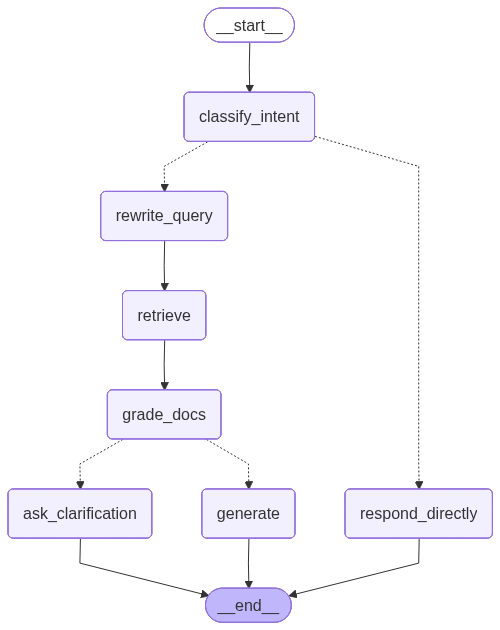

In [70]:
graph

In [71]:
# ── 11. 실행 헬퍼 ──────────────────────────────────────────
def chat(question: str, thread_id: str = "user-1") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config,
    )
    return result["messages"][-1].content

In [ ]:
chat("아 사이즈가 260으로 바꿔서 다시 추천해줘")

'| 판매처 | 상품명 | 가격 | 사이즈 | 주요 특징 | 이미지 | 링크 |\n|--------|--------|------|--------|------------|--------|------|\n| 크레이지11 | 나이키 줌 머큐리얼 베이퍼 16 프로 HG (FQ8686-600) | ₩119000 | 260 | 성인용, HG, 경량, 접지력 | ![이미지](https://www.crazy11.co.kr/shopimages/winv007/0010040031342.png?1752719180) | [🔗 제품 상세보기](https://www.crazy11.co.kr/shop/shopdetail.html?branduid=810761&search=%B8%D3%C5%A5%B8%AE%BE%F3+%BA%A3%C0%CC%C6%DB&sort=order&xcode=001&mcode=004&scode=001&GfDT=bW13UFg%3D) |\n| 크레이지11 | 나이키 줌 머큐리얼 베이퍼 16 프로 FG (FQ8685-600) | ₩119000 | 260 | 성인용, FG, 경량, 접지력 | ![이미지](https://www.crazy11.co.kr/shopimages/winv007/0010040031332.png?1752719280) | [🔗 제품 상세보기](https://www.crazy11.co.kr/shop/shopdetail.html?branduid=810760&search=%B8%D3%C5%A5%B8%AE%BE%F3+%BA%A3%C0%CC%C6%DB&sort=order&xcode=001&mcode=004&scode=001&GfDT=bmx7W1U%3D) |\n| 사커붐 | 줌 머큐리얼 베이퍼 16 프로 HG(FQ8686-600)(FQ8686600) | ₩140600 | 260 | 성인용, HG, 경량, 접지력 | ![이미지](https://soccerboom.co.kr/web/product/medium/202507/34faa0e47c7e22af666ef5dc0bcb51